In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

In [4]:
df = pd.read_csv('ecommerce_returns_synthetic_data.csv')

In [5]:
df.head()

,Order_ID,Product_ID,User_ID,Order_Date,Return_Date,Product_Category,Product_Price,Order_Quantity,Return_Reason,Return_Status,Days_to_Return,User_Age,User_Gender,User_Location,Payment_Method,Shipping_Method,Discount_Applied
0,ORD00000000,PROD00000000,USER00000000,2023-08-05,2024-08-26,Clothing,411.59,3,Changed mind,Returned,387.0,58,Male,City54,Debit Card,Next-Day,45.27
1,ORD00000001,PROD00000001,USER00000001,2023-10-09,2023-11-09,Books,288.88,3,Wrong item,Returned,31.0,68,Female,City85,Credit Card,Express,47.79
2,ORD00000002,PROD00000002,USER00000002,2023-05-06,NaN,Toys,390.03,5,NaN,Not Returned,NaN,22,Female,City30,Debit Card,Next-Day,26.64
3,ORD00000003,PROD00000003,USER00000003,2024-08-29,NaN,Toys,401.09,3,NaN,Not Returned,NaN,40,Male,City95,PayPal,Next-Day,15.37
4,ORD00000004,PROD00000004,USER00000004,2023-01-16,NaN,Books,110.09,4,NaN,Not Returned,NaN,34,Female,City80,Gift Card,Standard,16.37


In [6]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  object 
 1   Product_ID        10000 non-null  object 
 2   User_ID           10000 non-null  object 
 3   Order_Date        10000 non-null  object 
 4   Return_Date       5052 non-null   object 
 5   Product_Category  10000 non-null  object 
 6   Product_Price     10000 non-null  float64
 7   Order_Quantity    10000 non-null  int64  
 8   Return_Reason     5052 non-null   object 
 9   Return_Status     10000 non-null  object 
 10  Days_to_Return    5052 non-null   float64
 11  User_Age          10000 non-null  int64  
 12  User_Gender       10000 non-null  object 
 13  User_Location     10000 non-null  object 
 14  Payment_Method    10000 non-null  object 
 15  Shipping_Method   10000 non-null  object 
 16  Discount_Applied  10000 non-null  float64

In [7]:
df['Return_Status'].value_counts()

Return_Status
Returned        5052
Not Returned    4948
Name: count, dtype: int64

In [8]:
df['is_returned'] = df['Return_Status'].map({
    'Returned': 1,
    'Not Returned': 0
})

In [9]:
leakage_cols = [
    'Return_Status',
    'Return_Date',
    'Return_Reason',
    'Days_to_Return'
]

df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

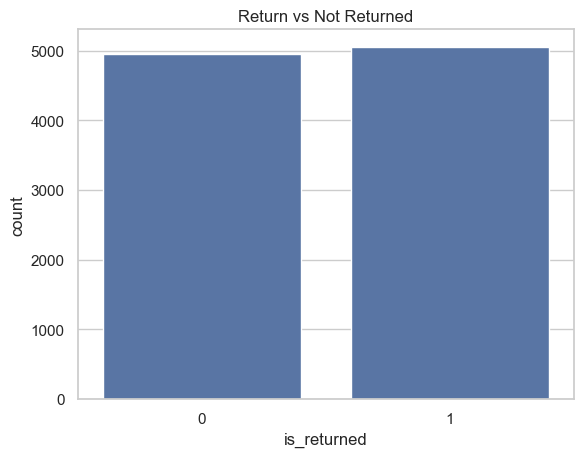

In [10]:
sns.countplot(x='is_returned', data=df)
plt.title("Return vs Not Returned")
plt.show()

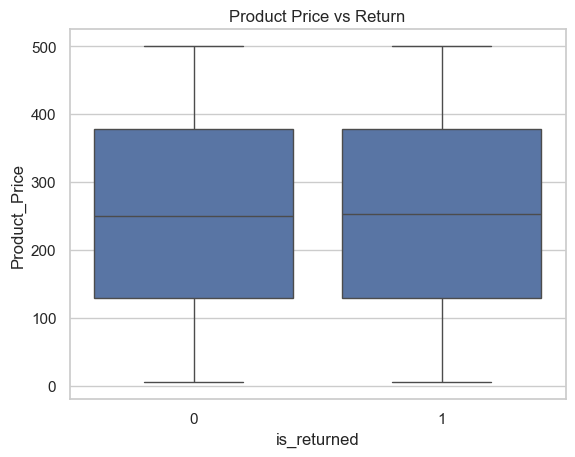

In [11]:
sns.boxplot(x='is_returned', y='Product_Price', data=df)
plt.title("Product Price vs Return")
plt.show()

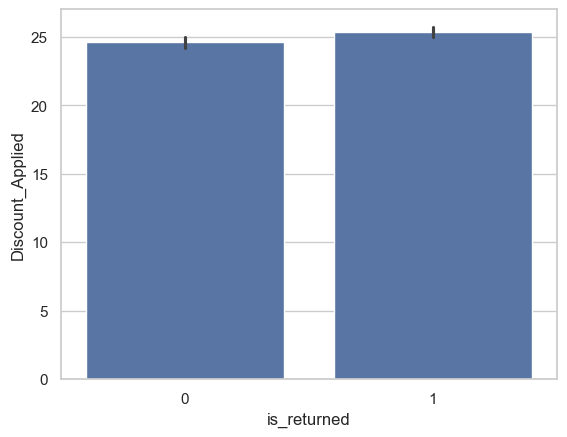

In [12]:
sns.barplot(x='is_returned', y='Discount_Applied', data=df)
plt.show()

In [13]:
for col in ['Product_Category', 'Shipping_Method', 'Payment_Method']:
    if col in df.columns:
        print(df[col].value_counts())

Product_Category
Books          2041
Home           2030
Clothing       2000
Electronics    1985
Toys           1944
Name: count, dtype: int64
Shipping_Method
Next-Day    3394
Express     3306
Standard    3300
Name: count, dtype: int64
Payment_Method
Gift Card      2537
Debit Card     2510
PayPal         2480
Credit Card    2473
Name: count, dtype: int64


In [14]:
df.isna().sum()

Order_ID            0
Product_ID          0
User_ID             0
Order_Date          0
Product_Category    0
Product_Price       0
Order_Quantity      0
User_Age            0
User_Gender         0
User_Location       0
Payment_Method      0
Shipping_Method     0
Discount_Applied    0
is_returned         0
dtype: int64

In [15]:
for col in df.select_dtypes(include='number'):
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

In [16]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df['order_day'] = df['Order_Date'].dt.day
df['order_month'] = df['Order_Date'].dt.month
df['order_weekday'] = df['Order_Date'].dt.weekday

df = df.drop(columns=['Order_Date'])

In [17]:
df_encoded = pd.get_dummies(
    df,
    columns=df.select_dtypes(include='object').columns,
    drop_first=True
)

In [18]:
df_encoded.shape
df_encoded.head()
df_encoded.isna().sum().sum()

np.int64(0)

In [19]:
df_encoded.head()

,Product_Price,Order_Quantity,User_Age,Discount_Applied,is_returned,order_day,order_month,order_weekday,Order_ID_ORD00000001,Order_ID_ORD00000002,...,User_Location_City95,User_Location_City96,User_Location_City97,User_Location_City98,User_Location_City99,Payment_Method_Debit Card,Payment_Method_Gift Card,Payment_Method_PayPal,Shipping_Method_Next-Day,Shipping_Method_Standard
0,411.59,3,58,45.27,1,5,8,5,False,False,...,False,False,False,False,False,True,False,False,True,False
1,288.88,3,68,47.79,1,9,10,0,True,False,...,False,False,False,False,False,False,False,False,False,False
2,390.03,5,22,26.64,0,6,5,5,False,True,...,False,False,False,False,False,True,False,False,True,False
3,401.09,3,40,15.37,0,29,8,3,False,False,...,True,False,False,False,False,False,False,True,True,False
4,110.09,4,34,16.37,0,16,1,0,False,False,...,False,False,False,False,False,False,True,False,False,True


In [20]:
df_encoded.to_csv("processed_returnss.csv", index=False)